In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd

from src.signals import SignalGenerator
from src.portfolio.constructor import PortfolioConstructor
from src.backtester import Backtester

In [3]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

In [4]:
signal_engine = SignalGenerator()

weekly_returns = signal_engine.weekly_returns(prices)

signals = signal_engine.generate_long_short_signals(
    weekly_returns
)

In [5]:
portfolio = PortfolioConstructor()

weights = portfolio.equal_weight_portfolio(signals)

In [6]:
backtester = Backtester()

In [7]:
strategy_returns = backtester.calculate_portfolio_returns(
    weights,
    weekly_returns
)

strategy_returns.head()

Date
2010-07-02    0.000000
2010-07-09    0.000000
2010-07-16   -0.185784
2010-07-23   -0.014493
2010-07-30   -0.018601
Freq: W-FRI, dtype: float64

In [8]:
backtester.summary(strategy_returns)

BACKTEST SUMMARY
Observations : 817
Mean Weekly Return : 0.2613%
Weekly Volatility : 6.9253%
Best Week : 29.4595%
Worst Week : -23.8358%


In [9]:
cumulative = backtester.cumulative_returns(
    strategy_returns
)

cumulative.tail()

Date
2026-01-23    1.146813
2026-01-30    1.169911
2026-02-06    1.312468
2026-02-13    1.280125
2026-02-20    1.218848
Freq: W-FRI, dtype: float64

<AxesSubplot:title={'center':'Long/Short Momentum Strategy'}, xlabel='Date'>

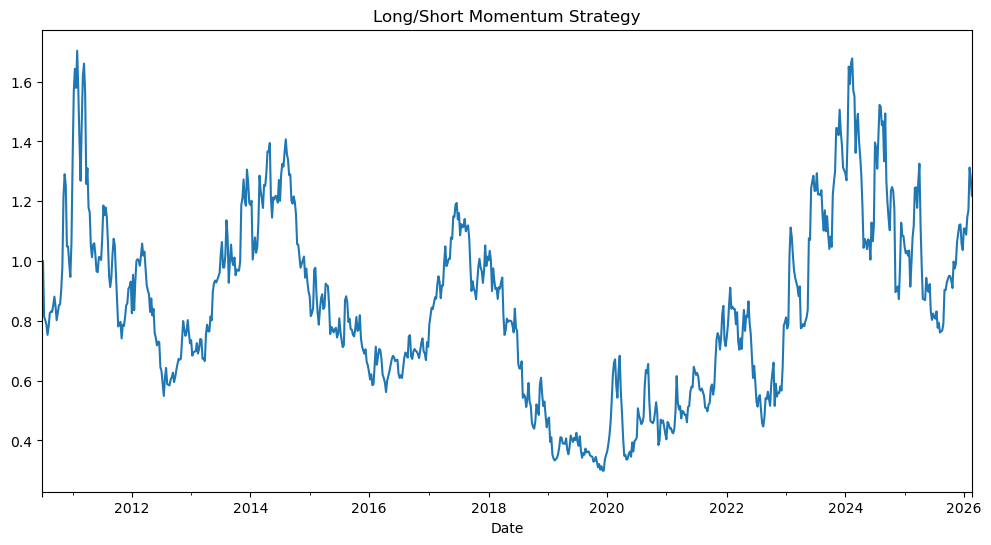

In [10]:
cumulative.plot(
    figsize=(12,6),
    title="Long/Short Momentum Strategy"
)